# Imports

- database for gene co-expression: https://coxpresdb.jp/gene_coexpression/?gene_id=7535&dataset=17
- topic modeling: https://github.com/gregversteeg/corex_topic/blob/master/corextopic/example/corex_topic_example.ipynb 


In [1]:
%reload_ext autoreload
%autoreload 2
import os
import anndata as ad
import numpy as np 
import pandas as pd 
import sys
import matplotlib.pyplot as plt
import scanpy as sc 
import decoupler as dc 
from scipy.stats import pearsonr
import json

sys.path.insert(0, '../')
from task_grn_inference.src.utils.util import colors_blind
from task_grn_inference.src.exp_analysis.helper import Exp_analysis, plot_interactions, create_interaction_info, create_interaction_df, jaccard_similarity, cosine_similarity, calculate_feature_distance, plot_cumulative_density
from task_grn_inference.src.utils.util import basic_qc
from sklearn.preprocessing import minmax_scale

task_grn_inference_dir = '../task_grn_inference'


par = {
        'method': 'pearson_corr',
        # 'method': 'portia',
        'models_dir': 'output/grn_models/pearson_corr',
        'input_dir': 'input/',
        'tf_all': f'{task_grn_inference_dir}/resources/prior/tf_all.csv',
        'models': [ 
                    'AS062_28',
                    'AS062_29',
                    'AS056_30',
                    'AS061_33',
                    'AS059_35',
                    'AS059_36',
                    
                    'AS056_61',
                    'AS051_66',
                    'AS056_73',
                    'AS062_73',
                    ]
    }

/home/jnourisa/miniconda3/envs/py10/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Data preprocessing

In [2]:
if False:
    # !ls /vol/projects/CIIM/Healthy_Single_Cell_Data/count_matrix	 
    # !ls /vol/projects/aehsani/ImmuneAgeing/Immuneageing_v2/data/datasets/
    !ls -l /vol/projects/CIIM/Healthy_Single_Cell_Data/initial_data_downloaded/pbmc_ageing/raw_counts_h5ad

In [2]:
if False: # subset data
    adata = ad.read_h5ad('/vol/projects/CIIM/Healthy_Single_Cell_Data/initial_data_downloaded/pbmc_ageing/raw_counts_h5ad/pbmc_gex_raw_with_var_obs.h5ad')
    obs = pd.read_csv('/vol/projects/CIIM/Healthy_Single_Cell_Data/initial_data_downloaded/pbmc_ageing/all_pbmcs/all_pbmcs_metadata.csv', index_col=0)

    obs = obs[['Batch', 'Donor_id','Age','Cluster_names']]
    obs.columns = ['batch', 'donor_id', 'age', 'cell_type']

    # group by
    df_selected = obs.groupby(['batch', 'age', 'cell_type']).size().sort_values()[::-1][:10].reset_index()
    print(df_selected)
    names = []
    for index, row in df_selected.iterrows():
        mask = (obs.batch==row.batch)&(obs.age==row.age)&(obs.cell_type==row.cell_type)
        adata_subset = adata[mask.reindex(adata.obs.index),:]
        # qc
        adata_subset = basic_qc(adata_subset)
        
        model_name = f"{row.batch}_{row.age}"
        to_save = f"{par['input_dir']}/{model_name}.h5ad"
        print(to_save)
        adata_subset.write(to_save)
        names.append(model_name)
if False: # to edit the adatas
    from task_grn_inference.src.process_data.perturbation.normalization.script import normalize_func
    for model_name in par['models']:
        model_file = f"{par['input_dir']}/{model_name}.h5ad"
        adata = ad.read_h5ad(model_file)
        adata.layers['counts'] = adata.X.copy()
        normalize_func(adata)
        adata.write(model_file)
if True: # merge them
    
    for i, model_name in enumerate(par['models']):
        model_file = f"{par['input_dir']}/{model_name}.h5ad"
        adata = ad.read_h5ad(model_file)
        adata.obs['label'] = model_name
        if i == 0:
            adata_concat = adata
        else:
            adata_concat = ad.concat([adata_concat, adata])
        if i > 6:
            break 

    sc.pp.highly_variable_genes(adata_concat, flavor='seurat_v3', batch_key='label', subset=True)
    sc.pp.normalize_total(adata_concat)
    sc.pp.log1p(adata_concat)
    sc.pp.scale(adata_concat)
    sc.pp.neighbors(adata_concat)
    sc.tl.umap(adata_concat)
    

NameError: name 'use' is not defined

/home/jnourisa/miniconda3/envs/py10/lib/python3.10/site-packages/scanpy/tools/_utils.py:41: UserWarning: You’re trying to run this on 2000 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  warnings.warn(


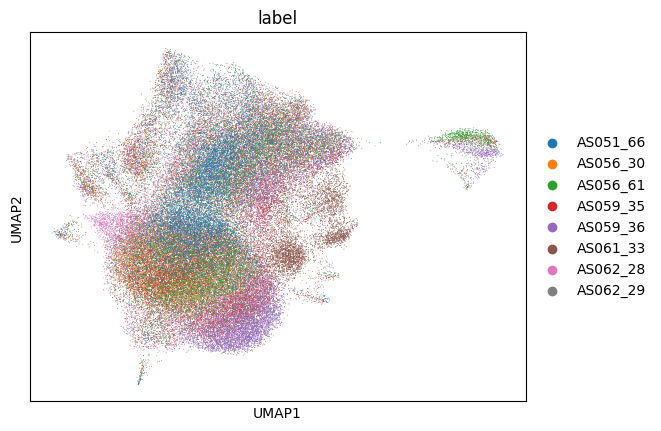

In [3]:

sc.pl.umap(adata_concat, color='label')

In [4]:
# check number of shared genes
if False:
    adatas = [ad.read_h5ad(f"{par['input_dir']}/{model}.h5ad") for model in par['models']]
    genes_prior = [adata.var_names for adata in adatas]
    shared_genes = genes_prior[0]
    for geneset in genes_prior:
        shared_genes = np.intersect1d(shared_genes, geneset)
    print('shared genes: ', shared_genes.shape)

# Annotations and GO

In [5]:
pathways = {
    "mTOR Pathway (Mammalian Target of Rapamycin)": "Regulates cell growth, protein synthesis, and metabolism. Overactivation is linked to aging and age-related diseases.",
    "AMPK Pathway (AMP-Activated Protein Kinase)": "Senses cellular energy levels and promotes metabolic homeostasis. Activation of AMPK is associated with increased longevity and protection against metabolic diseases.",
    "Autophagy Pathway": "The process of degrading and recycling damaged cellular components. Enhanced autophagy is associated with improved healthspan and longevity.",
    "p53 Pathway": "A tumor suppressor pathway that regulates cell cycle, apoptosis, and DNA repair. Hyperactivation of p53 is linked to cellular senescence and aging.",
    "NF-κB Pathway": "A major inflammatory pathway. Chronic activation of NF-κB is associated with inflammaging (age-related chronic inflammation) and age-related diseases.",
    "FOXO Transcription Factor Pathway": "Regulates genes involved in stress resistance, metabolism, and longevity. FOXO proteins, particularly FOXO3, play a role in lifespan regulation and cellular defense against oxidative stress.",
    "Wnt Signaling Pathway": "Involved in stem cell regulation and tissue homeostasis. Dysregulation of Wnt signaling is linked to aging and stem cell exhaustion.",
    "Senescence-Associated Secretory Phenotype (SASP)": "Senescent cells secrete pro-inflammatory cytokines, chemokines, and growth factors, contributing to chronic inflammation and tissue dysfunction during aging.",
    "Mitochondrial Dysfunction and Oxidative Stress Pathways": "Decline in mitochondrial function and increased production of reactive oxygen species (ROS) contribute to aging and age-related diseases.",
    "TGF-β Signaling Pathway": "Involved in cell proliferation, differentiation, and tissue regeneration. Alterations in TGF-β signaling are associated with fibrosis, senescence, and aging-related tissue dysfunction."
}

print(pathways.keys())

dict_keys(['mTOR Pathway (Mammalian Target of Rapamycin)', 'AMPK Pathway (AMP-Activated Protein Kinase)', 'Autophagy Pathway', 'p53 Pathway', 'NF-κB Pathway', 'FOXO Transcription Factor Pathway', 'Wnt Signaling Pathway', 'Senescence-Associated Secretory Phenotype (SASP)', 'Mitochondrial Dysfunction and Oxidative Stress Pathways', 'TGF-β Signaling Pathway'])


In [6]:
if False: #gsea gene sets 
    def read_gmt(file_path):
        gene_sets = {}
        with open(file_path, 'r') as file:
            for line in file:
                parts = line.strip().split('\t')
                gene_set_name = parts[0]
                gene_set_description = parts[1]
                genes = parts[2:]
                gene_sets[gene_set_name] = {
                    'description': gene_set_description,
                    'genes': genes
                }
        return gene_sets

    # Read the GMT file
    gene_sets_raw = read_gmt('input/prior/h.all.v2024.1.Hs.symbols.gmt') # canonical
    # gene_sets = read_gmt('input/prior/c2.cp.v2024.1.Hs.symbols.gmt') # 

    import numpy as np
    gene_sets_raw = {key:gs['genes'] for key, gs in gene_sets_raw.items()}
    
    
    
    # # extract relevant sets 
    gene_sets = {}
    map_dict = {'HALLMARK_PI3K_AKT_MTOR_SIGNALING': 'PI3K_AKT_MTOR', 'HALLMARK_MTORC1_SIGNALING':'MTORC1', 'HALLMARK_P53_PATHWAY':'P53', 'HALLMARK_TNFA_SIGNALING_VIA_NFKB':'TNFA_NFKB',
                'HALLMARK_WNT_BETA_CATENIN_SIGNALING':'WNT_BETA_CATENIN', 'HALLMARK_OXIDATIVE_PHOSPHORYLATION': 'OXIDATIVE_PHOSPHORYLATION', 'HALLMARK_TGF_BETA_SIGNALING':'TGF_BETA'}
    for key, key_simple in map_dict.items():
        gene_sets[key_simple] = gene_sets_raw[key]
    with open('output/gene_sets.json', 'w') as f:
        json.dump(gene_sets, f)

In [7]:
if False:
    for key in gene_sets_raw.keys():
        # if ('antigen' in key.lower()) & ('bind' in key.lower()):
        if ('tgf' in key.lower()) :
            print(key)

# Run GRNs

In [9]:

if True:
    images_dir = '../../images'
    par['layer'] = 'pearson'
    method = 'pearson_corr'
    par['models_dir'] = f"output/grn_models/{method}_{par['layer']}"
    par['num_workers'] = 20
    par['max_n_links'] = 1_000_000
    par['corr_t'] = 0.05
    par['mem'] = "64G"
    par['time'] = "24:00:00"

    os.makedirs(par['models_dir'], exist_ok=True)
    for model in par['models']:
        prediction = f"{par['models_dir']}/{model}.csv"
        rna = f"{par['input_dir']}/{model}.h5ad"
        
        method_args = f"--resources_dir {task_grn_inference_dir}/src/utils \
                        --multiomics_rna {rna} \
                        --tf_all {par['tf_all']} \
                        --prediction {prediction} \
                        --num_workers  {par['num_workers']} \
                        --max_n_links {par['max_n_links']} \
                        --corr_t {par['corr_t']} \
                        --layer {par['layer']}"
                        
        if method in ["grnboost2", "scenic", "genie3"]:
            command = f"singularity exec {images_dir}/scenic python {task_grn_inference_dir}/src/methods/single_omics/{method}/script.py {method_args}" 
        if method=='pearson_corr':
            method_args+= " --no_tf_subset"
            command = f"python {task_grn_inference_dir}/src/control_methods/pearson/script.py {method_args}" 
        elif method in ["grnboost2", "scenic", "genie3"]:
            command = f"singularity exec {images_dir}/scenic python {task_grn_inference_dir}/src/methods/single_omics/{method}/script.py {method_args}" 
        else:
            command = f"singularity exec {images_dir}/{method} python {task_grn_inference_dir}/src/methods/single_omics/{method}/script.py {method_args}"        

        tag = f"--job-name {model} "
        print(tag)
        resources = f" --cpus-per-task {par['num_workers']} --mem {par['mem']} --time {par['time']}" #resources
        tag+=resources

        # !sbatch {tag} ../task_grn_inference/scripts/sbatch/grn_inference.sh "{command}"
        !bash ../task_grn_inference/scripts/sbatch/grn_inference.sh "{command}" 
        

--job-name AS062_28 
{'multiomics_rna': 'input//AS062_28.h5ad', 'tf_all': '../task_grn_inference/resources/prior/tf_all.csv', 'cell_type_specific': False, 'max_n_links': 1000000, 'prediction': 'output/grn_models/pearson_corr_pearson/AS062_28.csv', 'seed': 32, 'normalize': False, 'num_workers': '20', 'no_tf_subsetting': True, 'corr_t': 0.05, 'layer': 'pearson', 'causal': True}
Read data
pearson
calculate correlation
process corr results
conver to df
Corr results are ready
Output GRN
--job-name AS062_29 
{'multiomics_rna': 'input//AS062_29.h5ad', 'tf_all': '../task_grn_inference/resources/prior/tf_all.csv', 'cell_type_specific': False, 'max_n_links': 1000000, 'prediction': 'output/grn_models/pearson_corr_pearson/AS062_29.csv', 'seed': 32, 'normalize': False, 'num_workers': '20', 'no_tf_subsetting': True, 'corr_t': 0.05, 'layer': 'pearson', 'causal': True}
Read data
pearson
calculate correlation
process corr results
conver to df
Corr results are ready
Output GRN
--job-name AS056_30 
{'mul

# Feature analysis

In [10]:
# create exp objs
exp_objs_dict = {}
for model in par['models']:
    par['grn_model'] = f"{par['models_dir']}/{model}.csv"
    net = pd.read_csv(par['grn_model'])    
    obj = Exp_analysis(net)
    stats = obj.calculate_basic_stats()
    print(stats)
    # obj.determine_source_properties()
    exp_objs_dict[model] = obj

{'n_links': 313687, 'n_source': 12638, 'n_target': 12876, 'ratio_positive_negative': 0.7212699283043288}
{'n_links': 334934, 'n_source': 13175, 'n_target': 13312, 'ratio_positive_negative': 0.7724088924982235}
{'n_links': 280431, 'n_source': 12908, 'n_target': 12957, 'ratio_positive_negative': 0.8459621083261123}
{'n_links': 244179, 'n_source': 11598, 'n_target': 11793, 'ratio_positive_negative': 0.7078782368672163}
{'n_links': 335832, 'n_source': 13030, 'n_target': 13083, 'ratio_positive_negative': 0.7882721122465995}
{'n_links': 352094, 'n_source': 12817, 'n_target': 12977, 'ratio_positive_negative': 0.7549773639993865}
{'n_links': 344431, 'n_source': 12837, 'n_target': 12851, 'ratio_positive_negative': 0.7555940086693707}
{'n_links': 237360, 'n_source': 12519, 'n_target': 12559, 'ratio_positive_negative': 0.8233779912369397}
{'n_links': 250723, 'n_source': 12177, 'n_target': 12436, 'ratio_positive_negative': 0.7653665599087439}
{'n_links': 412465, 'n_source': 13355, 'n_target': 1338

In [11]:
# extract stats 
nets = {key:obj.net for key, obj in exp_objs_dict.items()}
nets_top = {key:obj.subset_quantile(obj.net, top_n=1000) for key, obj in exp_objs_dict.items()}
active_sum_degree = {key:obj.calculate_feature(obj.net, feature='active_sum_degree').reset_index() for key, obj in exp_objs_dict.items()}
active_sum_degree_top = {key:Exp_analysis.subset_quantile(df, col_name='feature', top_n=100) for key, df in active_sum_degree.items()}

# passive_sum_degree = {key:obj.calculate_feature(obj.net, feature='passive_sum_degree').reset_index() for key, obj in exp_objs_dict.items()}
# passive_sum_degree_top = {key:Exp_analysis.subset_quantile(df, col_name='feature', top_n=100) for key, df in passive_sum_degree.items()}

/vol/tmp/users/jnourisa/ipykernel_90356/3344224930.py:8: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/home/jnourisa/miniconda3/envs/py10/lib/python3.10/site-packages/IPython/core/events.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
/home/jnourisa/miniconda3/envs/py10/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


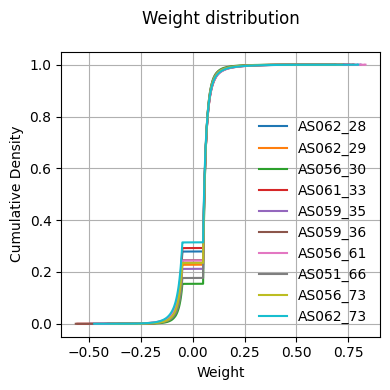

In [12]:
# weight cdf
fig, ax = plt.subplots(1, 1, figsize=(4, 4))
for i_plot, (name, obj) in enumerate(exp_objs_dict.items()):
    plot_cumulative_density(obj.net.weight, ax=ax)
    ax.lines[-1].set_label(name)
    ax.legend(frameon=False)
ax.set_title('Weight distribution', pad=20)
plt.tight_layout()

## Selected genes sets

In [42]:
with open('output/gene_sets.json', 'r') as f:
    gene_sets = json.load(f)
top_n = 100
gene_set_name = 'TNFA_NFKB' #''PI3K_AKT_MTOR', 'MTORC1', 'P53', 'TNFA_NFKB', 'WNT_BETA_CATENIN', 'OXIDATIVE_PHOSPHORYLATION', 'TGF_BETA'
gene_set = gene_sets[gene_set_name]

In [43]:
if True:
    for name, net in nets.items():
        union_genes = np.union1d(net['source'], net['target'])
        print(name, len(union_genes), np.intersect1d(union_genes, gene_set).shape)
        break

AS062_28 14592 (160,)


In [44]:
# def full_pipeline(nets, gene_set, gene_set_name, top_n)
nets_sub = {name: net[net.source.isin(gene_set)&net.target.isin(gene_set)] for name, net in nets.items()}
nets_sub = {key: net.sort_values(by='weight', ascending=False, key=abs).head(top_n) for key, net in nets_sub.items()} # keep top 100 links

In [45]:
if False:
    def log_quantile_transformation(net_o):
        from sklearn.preprocessing import QuantileTransformer
        net = net_o.copy()
        data = net.weight.values
        log_data = np.log1p(data)  # log(x + 1) to avoid log(0)
        quantile_transformer = QuantileTransformer(output_distribution='normal')
        transformed_data = quantile_transformer.fit_transform(log_data.reshape(-1, 1))
        net['weight'] = transformed_data
        return net
    nets_sub_zscores = {name:log_quantile_transformation(net) for name, net in nets_sub.items()}

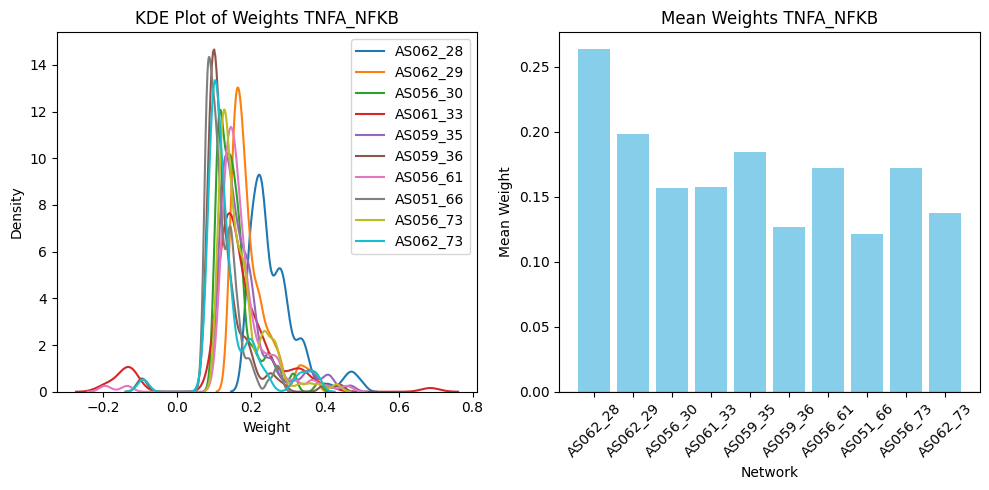

In [46]:
import seaborn as sns
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
for key, net in nets_sub.items():
    sns.kdeplot(net['weight'], bw_adjust=0.5, ax=ax1, label=key)
ax1.set_title(f'KDE Plot of Weights {gene_set_name}')
ax1.set_xlabel('Weight')
ax1.set_ylabel('Density')
ax1.legend()

# Calculate mean weights for each network
mean_weights = {key: net['weight'].mean() for key, net in nets_sub.items()}
ax2.bar(mean_weights.keys(), mean_weights.values(), color='skyblue')
ax2.axhline(0, color='black', linewidth=0.8)  # Add a horizontal line at y=0 for reference

# Customize the bar plot
ax2.set_title(f'Mean Weights {gene_set_name}')
ax2.set_xlabel('Network')
ax2.set_ylabel('Mean Weight')
ax2.set_xticks(list(mean_weights.keys()))  # Ensure all keys are shown on x-axis
ax2.set_xticklabels(list(mean_weights.keys()), rotation=45)

plt.tight_layout()
plt.show()

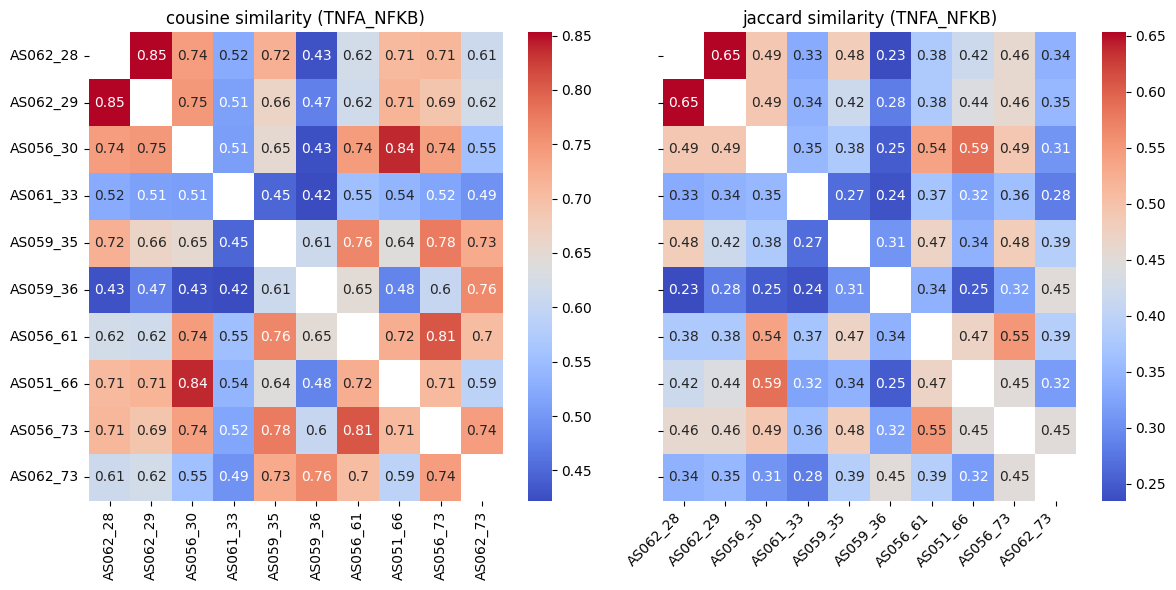

In [47]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6), sharey=True)
cousine_matrix, fig = cosine_similarity(nets_sub, col_name='link', weight_col='weight', figsize=(5.5, 4.5), ax=ax1, title=f'cousine similarity ({gene_set_name})')
jaccard_matrix, fig = jaccard_similarity(nets_sub, col_name='link', figsize=(5.5, 4.5), ax=ax2, title=f'jaccard similarity ({gene_set_name})')
plt.tight_layout()


['AS062_28', 'AS062_29', 'AS056_30', 'AS061_33', 'AS059_35', 'AS059_36', 'AS056_61', 'AS051_66', 'AS056_73', 'AS062_73']


Text(0.5, 1.0, 'TNFA_NFKB')

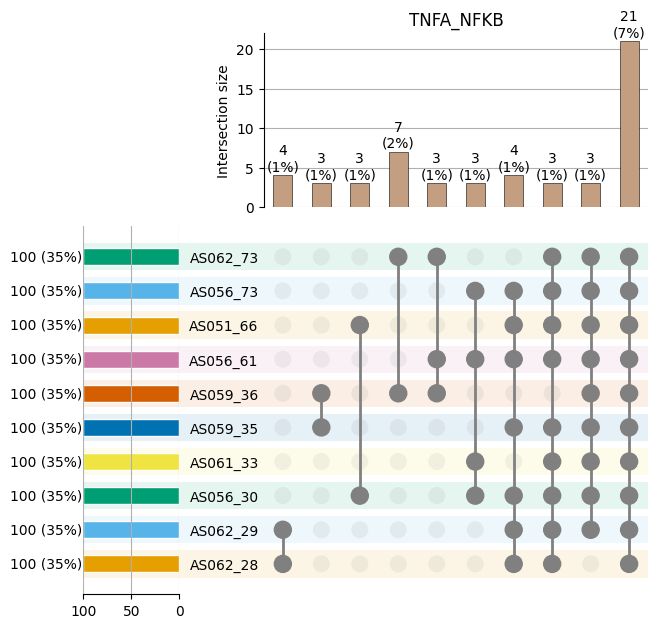

In [48]:
nets_sub_q_dict = {name:df.link.values for name, df in nets_sub.items()}
interaction_df = create_interaction_df(nets_sub_q_dict)
fig = plot_interactions(interaction_df, min_degree=2, min_subset_size=3)
plt.title(gene_set_name)

In [49]:
aaa

NameError: name 'aaa' is not defined

## Centrality

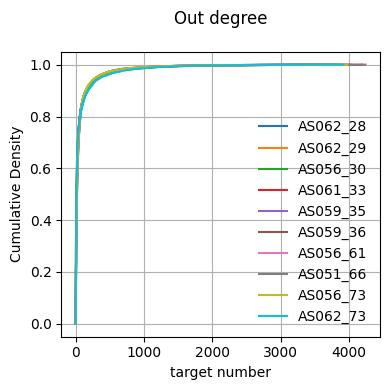

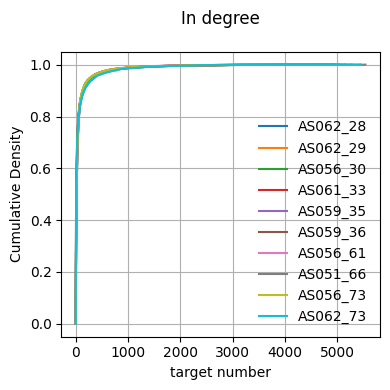

In [195]:
# out degree centrality
fig, ax = plt.subplots(1, 1, figsize=(4, 4))
for i_plot, (name, obj) in enumerate(exp_objs_dict.items()):
    obj.calculate_centrality()
    obj.plot_centrality(obj.tf_gene.out_deg.degree, ax=ax, x_label='target number')
    ax.lines[-1].set_label(name)
ax.legend(frameon=False)
ax.set_title('Out degree', pad=20)
plt.tight_layout()
# in degree centrality
fig, ax = plt.subplots(1, 1, figsize=(4, 4))
for i_plot, (name, obj) in enumerate(exp_objs_dict.items()):
    obj.calculate_centrality()
    obj.plot_centrality(obj.tf_gene.in_deg.degree, ax=ax, x_label='target number')
    ax.lines[-1].set_label(name)
ax.legend(frameon=False)
ax.set_title('In degree', pad=20)
plt.tight_layout()

In [196]:
#TODO: add hierachical clustering

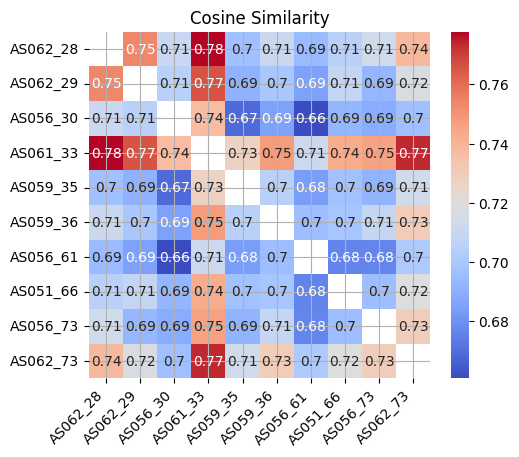

In [197]:
# cousine_matrix, fig = cosine_similarity(active_sum_degree_top, col_name='source', weight_col='feature', figsize=(5.5, 4.5))
cousine_matrix, fig = cosine_similarity(nets, col_name='link', weight_col='weight', figsize=(5.5, 4.5))

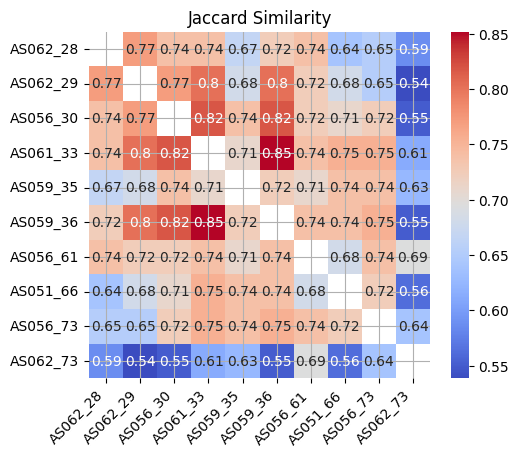

In [198]:
jaccard_matrix, fig = jaccard_similarity(active_sum_degree_top, col_name='source', figsize=(5.5, 4.5))

In [199]:

def merge_distance_metrics(distance_dict):
    for i, (name, df) in enumerate(distance_dict.items()): 
        df.columns = [f'{col}_{name}' for col in df.columns]
        if i==0:
            df_merged = df
        else: #first match the index 
            common_index = pd.Index(np.union1d(df_merged.index, df.index))
            df = df.reindex(common_index).fillna(0)
            df_merged = df_merged.reindex(common_index).fillna(0)
            df_merged = pd.concat([df_merged, df], axis=1)
    return df_merged
def rank_distance(df_distance: pd.DataFrame) -> pd.DataFrame:
    '''
        Receives a distance df, normalizes the scores for each column, and creates a rank for each column and also one overall
    '''
    df_n = df_distance.abs()/df_distance.abs().max(axis=0)
    df_n.fillna(0, inplace=True)
    for name in df_distance.columns:
        df_distance[f'rank_{name}'] = df_n[name].rank(ascending=False)
    df_distance['rank'] = df_n.sum(axis=1).rank(ascending=False)
    df_distance.sort_values(by='rank')
    return df_distance
def heat_map(df):
    import pandas as pd
    import seaborn as sns
    import matplotlib.pyplot as plt
    fig, ax = plt.subplots(1, 1, figsize=(1.2*df.shape[1], .2*df.shape[0]))
    sns.heatmap(df, annot=False, cmap='coolwarm', cbar=True, linewidths=0.5, ax=ax, cbar_kws={'label': 'Distance'})

    ax.xaxis.tick_top()
    ax.tick_params(axis='x', rotation=45)
    ax.set_ylabel('Genes')
    plt.tight_layout()

def contrast_analysis(nets, control_tag):
    # feature for each net
    feature_dict = {}
    for name, net in nets.items():
        net = process_net(net, top_q_net=top_q_net) # preprocessing, e.g. top quantile 
        feature_dict[name] = calculate_feature(net, feature=feature, mode=mode)  # feature calcualtion
    # distance 
    distance_dict = {}
    for name, feature_df in feature_dict.items():
        if name == control_tag:
            continue
        distance_dict[name] = calculate_distance(feature_df, feature_dict[control_tag], top_n) # distance 
    # merge and rank
    merged_distance = merge_distance_metrics(distance_dict)
    # ranked_distance = rank_distance(merged_distance)
    return merged_distance

In [200]:

feature = 'active_sum_degree'
top_n = 100 # top number of items based on the contrast between samples
mode = 'rank'


groups = [['AS062_28', 'AS062_29', 'AS062_73'], ['AS056_30', 'AS056_61', 'AS056_73']]
groups_young_old = [['AS062_29', 'AS062_73'], ['AS056_30', 'AS056_73']]
groups_young_young = [['AS062_29', 'AS062_28']]
groups_old_old = [['AS056_61', 'AS056_73']]

distance_repo = []
for group in groups_young_old:
    control = group[0]
    sample = group[1]
    nets_g = {key:nets[key] for key in group}
    merged_distance = contrast_analysis(nets_g, control)
    distance_repo.append(merged_distance)
tfs_young_old = np.intersect1d(distance_repo[0].index, distance_repo[1].index)

# distance_repo = []
# for group in groups_young_young:
#     control = group[0]
#     sample = group[1]
#     nets_g = {key:nets[key] for key in group}
#     merged_distance = contrast_analysis(nets_g, control)
#     distance_repo.append(merged_distance)
# tfs_young_young = distance_repo[0].index

# distance_repo = []
# for group in groups_old_old:
#     control = group[0]
#     sample = group[1]
#     nets_g = {key:nets[key] for key in group}
#     merged_distance = contrast_analysis(nets_g, control)
#     distance_repo.append(merged_distance)
# tfs_old_old = distance_repo[0].index


NameError: name 'process_net' is not defined

In [48]:
distance_repo

[        distance_raw_AS062_73  distance_rank_AS062_73
 AIRE                      2.0                     7.0
 ANXA1                    23.0                     2.0
 BACH2                    -2.0                    -1.5
 BAX                       1.0                    33.5
 BCL11B                    2.0                     7.0
 ...                       ...                     ...
 ZNF331                   -9.0                   -62.0
 ZNF384                    0.0                    -5.0
 ZNF451                    0.0                    -5.0
 ZNF565                    0.0                    -5.0
 ZNF706                    0.0                    -5.0
 
 [64 rows x 2 columns],
          distance_raw_AS056_73  distance_rank_AS056_73
 ANXA1                      2.0                     1.0
 BACH2                     -4.0                    -3.5
 BCL11B                    -3.0                   -10.5
 BHLHE40                    0.0                    -0.5
 DRAP1                     -1.0   

In [32]:
df = merged_distance.sort_values(by='distance_rank_AS062_73', key=abs, ascending=False).head(10)[['distance_raw_AS062_73', 'distance_rank_AS062_73']]
# df.columns = 
# heat_map(df)
df.head(10)

,distance_raw_AS062_73,distance_rank_AS062_73
ZEB2,30.0,67.5
UBB,18.0,63.5
FOSB,-10.0,-63.5
ZNF331,-9.0,-62.0
TPI1,-5.0,-57.5
FANK1,7.0,54.5
HSPA5,-2.0,-52.5
ELF1,-1.0,-44.5
UBTF,-1.0,-44.5
KLF2,-192.0,-35.5


## Edge based

['AS062_28', 'AS062_29', 'AS056_30', 'AS061_33', 'AS059_35', 'AS059_36', 'AS056_61', 'AS051_66', 'AS056_73', 'AS062_73']


IndexError: list index out of range

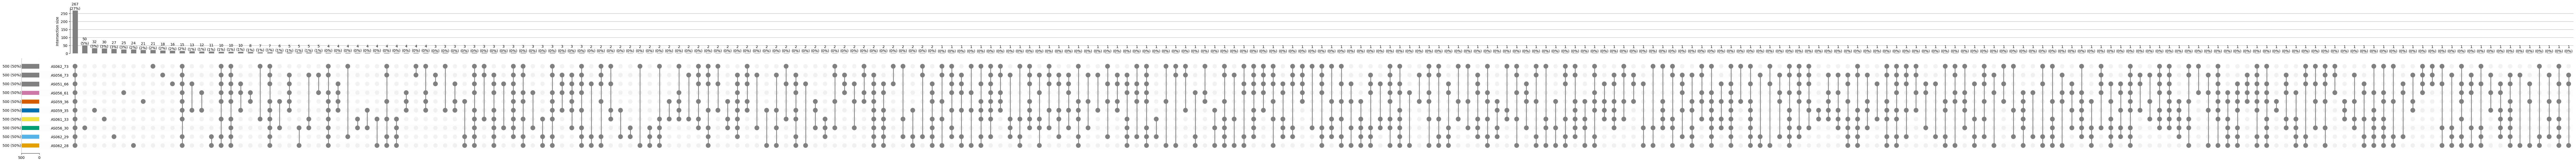

In [11]:
# top quantile edges
thresh = 0.99 #quantile
top_cases = {}
for name, obj in exp_objs_dict.items():
    top_cases[name] = obj.top_edges(thresh)
interaction_df = create_interaction_df(top_cases)
aa = plot_interactions(interaction_df)

In [13]:

# networkx plot
if False:
    import matplotlib.pyplot as plt
    def create_g_graph(net):
        import networkx as nx
        G = nx.Graph()
        for source, target, weight in zip(net.source, net.target, net.weight):
            G.add_edge(source, target, weight=weight)
        return G 
    G = create_g_graph(exp_objs_dict['young'].net.iloc[:200, :])
    pos = nx.circular_layout(G)

    # Draw the network
    plt.figure(figsize=(8,8))
    nx.draw(G, pos, with_labels=True, node_size=10, node_color='lightblue', font_size=10, font_color='black')

    # Draw edges with varying thickness based on weights
    edges = G.edges(data=True)
    nx.draw_networkx_edges(G, pos, edgelist=edges, width=[d['weight']*.01 for (u, v, d) in edges], alpha=0.7)

    plt.show()

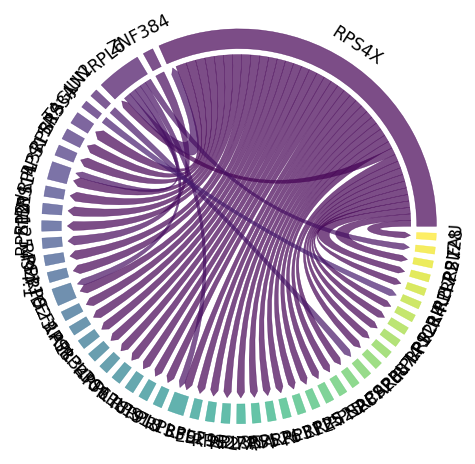

In [14]:
# !pip install mpl-chord-diagram

def cord_plot(net):
    import matplotlib.pyplot as plt
    import numpy as np
    from mpl_chord_diagram import chord_diagram
    net.weight = net.weight/net.weight.max()
    
    matrix = net.pivot(index='source', columns='target', values='weight')
    nodes = pd.Index(net['source'].tolist() + net['target'].tolist()).unique()
    matrix = matrix.reindex(index=nodes, columns=nodes)
    matrix = matrix.fillna(0)

    flux = matrix.values
    names = matrix.index
    args = dict(
    chord_colors=None,
    colors=None,
    alpha=0.7,
    width=.1,
    min_chord_width = 0,
    fontsize=12.5,
    
    )
    chord_diagram(flux, names, directed=True, **args)
net = obj.net.sort_values(by='weight', ascending=False)[:50]
cord_plot(net)
plt.show()


In [15]:
# net

In [16]:
exc_case1= interaction_df[interaction_df.young * (~interaction_df.old)].index
print('Young: ', exc_case1)
exc_case1 = interaction_df[interaction_df.old * (~interaction_df.young)].index
print('Old: ', exc_case1)

Young:  Index(['JUN_UBC', 'PRDM1_S100A4', 'RPL6_UXT', 'EGR1_IER2', 'EEF1D_RPL18',
       'ID2_IER2', 'RPL6_HSPA8', 'EEF1D_RPS9', 'EEF1D_RACK1', 'RPL35_EEF1B2',
       ...
       'PRDM1_IL32', 'EEF1D_RPL5', 'RPL6_YBX1', 'RPS4X_EIF2S3', 'RPS4X_HLA-B',
       'RPL6_ATP5F1E', 'JUN_AC004448.2', 'YWHAZ_TMSB4X', 'YBX1_PFN1',
       'FOSB_ERCC1'],
      dtype='object', length=104)
Old:  Index(['FOS_RPS26', 'FOXP3_IL32', 'RPL35_RPL41', 'RPS4X_TXNIP', 'STAT1_B2M',
       'FOXP3_STAM', 'TAGLN2_LRRFIP1', 'JUNB_RPS26', 'STAT1_PSME2',
       'RPS4X_TCF7',
       ...
       'UBTF_AC004596.1', 'RPL6_TOMM7', 'ZNF133_AL049646.1', 'STAT1_HLA-E',
       'RPS4X_FLT3LG', 'RPS4X_RSL1D1', 'TAGLN2_CD52', 'RPL6_SMDT1',
       'RPS4X_FTH1', 'YWHAZ_HLA-A'],
      dtype='object', length=104)


## Node based

### Differential central TFs

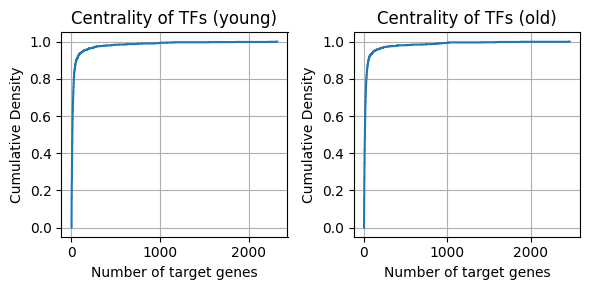

In [17]:
par = {
    'top_n_tfs': 50
}
par['n_contrast'] = len(exp_objs_dict)

oo = {}

fig, axes = plt.subplots(1, par['n_contrast'], figsize=(3*par['n_contrast'], 3))
for i, (name, obj) in enumerate(exp_objs_dict.items()):
    ax=axes[i]
    obj.plot_cumulative_density(obj.sources.degree, ax=ax)
    ax.set_xlabel('Number of target genes')
    ax.set_title(f'Centrality of TFs ({name})')
oo['fig_cdf'] = fig
plt.tight_layout()

['young', 'old']


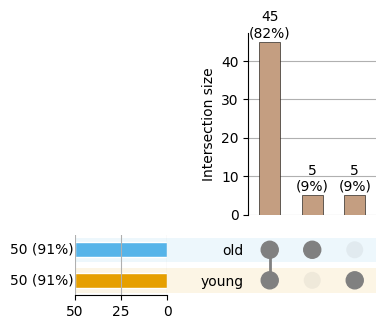

In [18]:
models = list(exp_objs_dict.keys())

central_tfs_dfs = {}
for name, obj in exp_objs_dict.items():
    df = obj.sources.sort_values(by='degree', ascending=False)[:par['top_n_tfs']]
    central_tfs_dfs[name] = df
    
central_tfs = {name:df.index for name, df in central_tfs_dfs.items()}
# shared and exclusive tfs
oo['shared_central_tfs'] = np.intersect1d(central_tfs[models[0]], central_tfs[models[1]])
oo[f'ex_{models[0]}_central_tfs'] = np.setdiff1d(central_tfs[models[0]], central_tfs[models[1]])
oo[f'ex_{models[1]}_central_tfs'] = np.setdiff1d(central_tfs[models[1]], central_tfs[models[0]])
# interaction plot
interaction_df = create_interaction_df(central_tfs)
fig = plot_interactions(interaction_df)
oo['fig_interactions'] = fig

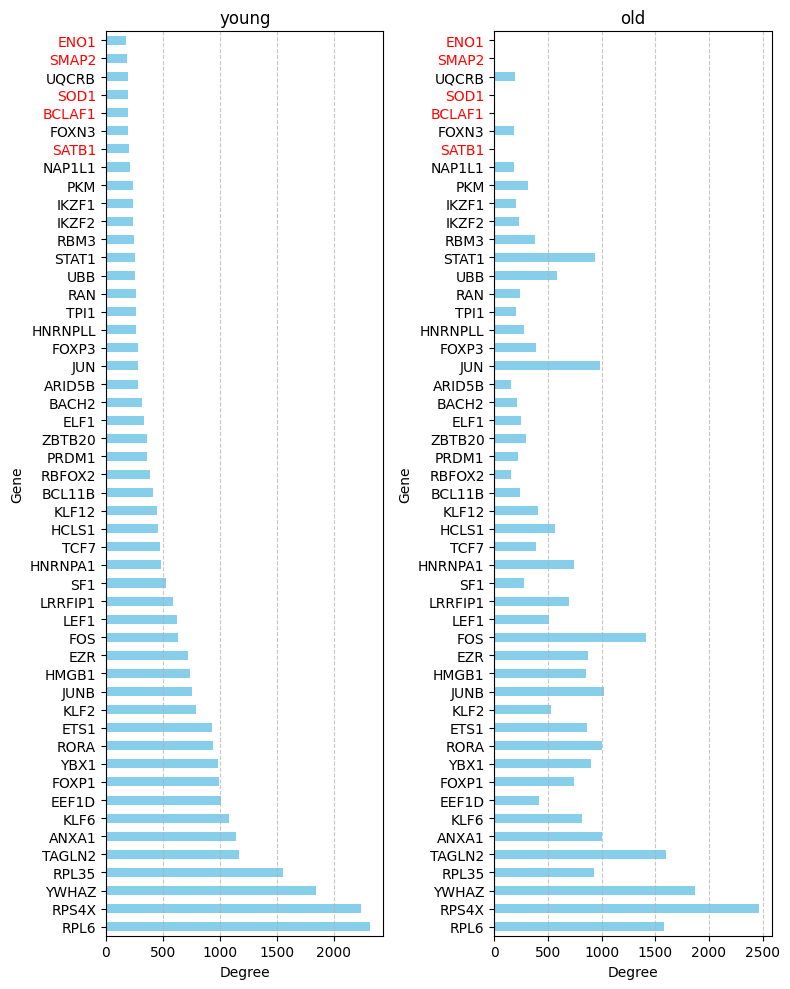

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(8, 10))
df_base = None
for i, (name, obj) in enumerate(exp_objs_dict.items()):
    ax = axes[i]
    df = central_tfs_dfs[name]
    if i==0:
        df_base = df
    else:
        df = df.reindex(df_base.index)
    colors = ['black' if name in oo['shared_central_tfs'] else 'red' for name in df.index]
    obj.plot_centrality(df, title=name, ax=ax, colors=colors)

plt.tight_layout()

In [20]:
# regulatory links
links_n = {}
source_n = {}
target_n = {}

for name, obj in exp_objs.items():
    grn = obj.net
    if 'cell_type' in grn.columns: # for cell specific grn models, take the mean
        n_grn = grn.groupby('cell_type').size().mean()
    else:
        n_grn = len(grn)
    links_n[name] = n_grn
    source_n[name] = obj.stats['n_source']
    target_n[name] = obj.stats['n_target']


NameError: name 'exp_objs' is not defined

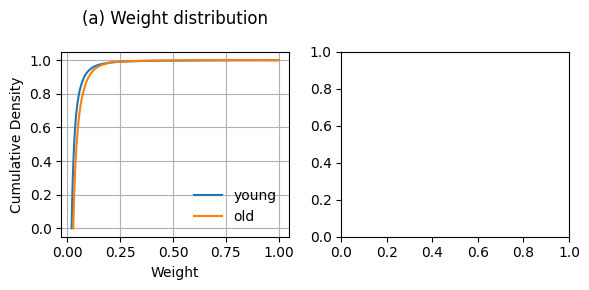

In [102]:
# tf gene: in degree
fig, axes = plt.subplots(1, 2, figsize=(6, 3))
for i_plot, (name, obj) in enumerate(zip(par['grn_models'], exp_objs)):
    ax = axes[0]
    obj.plot_grn_cdf(ax)
    ax.lines[-1].set_label(name)
    ax.legend(frameon=False)
    ax.set_title('(a) Weight distribution', pad=20)
    x = axes[1]
    
plt.tight_layout()

['young', 'old']
['young', 'old']
['old', 'young']


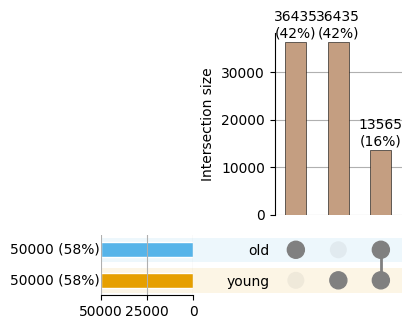

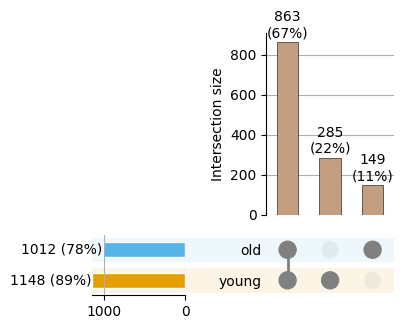

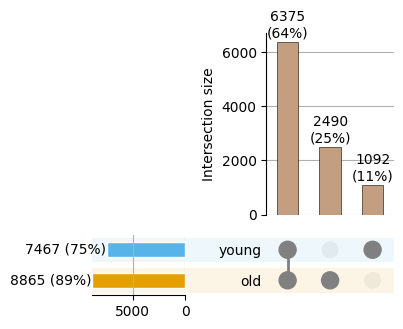

In [14]:
interaction_info = create_interaction_info(exp_objs_dict)
fig = plot_interactions(interaction_info['links'], min_subset_size = None, min_degree=None)    
# fig.savefig(f'{results_folder}/explanatory_analysis/figs/links_interactions.png', dpi=300, transparent=True,  bbox_inches='tight')
fig = plot_interactions(interaction_info['source'], min_subset_size = None, min_degree=None) 
# fig.savefig(f'{results_folder}/explanatory_analysis/figs/TFs_interactions.png', dpi=300, transparent=True, bbox_inches='tight')
fig = plot_interactions(interaction_info['target'], min_subset_size = None, min_degree=None) 

# EDA
- dominance of male
- these cell types look sufficiently represented: ['CD4+ T cells', 'Myeloid cells', 'TRAV1-2- CD8+ T cells', 'NK cells']
- 

In [4]:
bins = 5

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
obs['age_bins'] = pd.cut(obs['Age'], bins=bins).apply(lambda x: f"{int(x.left)}-{int(x.right)}")  # Adjust bins as necessary
sns.set(style="whitegrid")


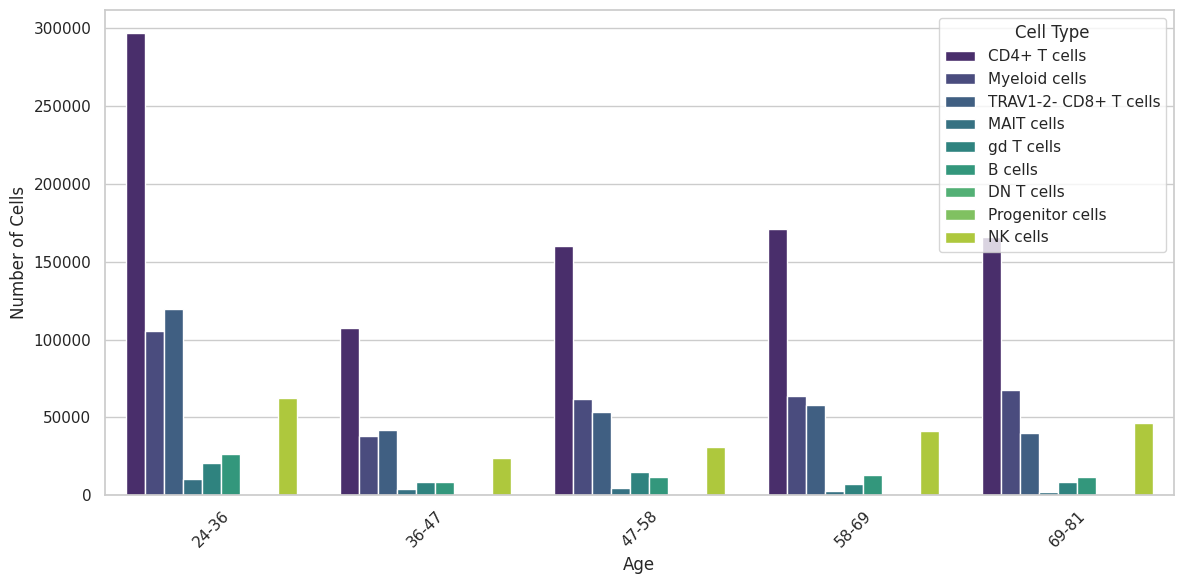

In [5]:

plt.figure(figsize=(12, 6))
sns.countplot(data=obs, x='age_bins', hue='Cluster_names', palette='viridis')

plt.xlabel('Age')
plt.ylabel('Number of Cells')
plt.legend(title='Cell Type')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



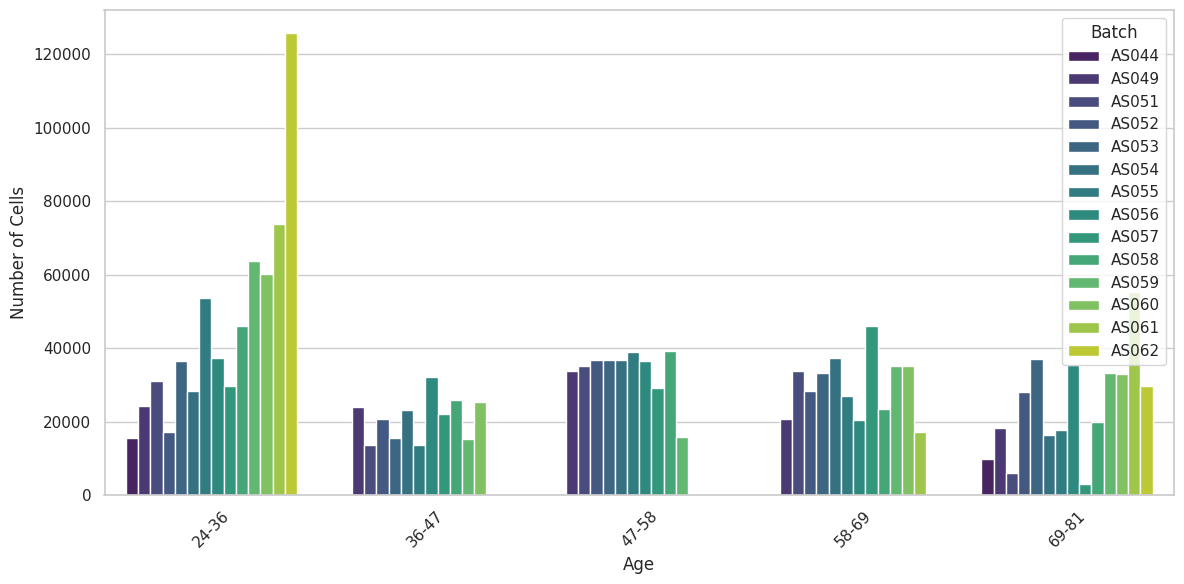

In [6]:

plt.figure(figsize=(12, 6))
sns.countplot(data=obs, x='age_bins', hue='Batch', palette='viridis')

plt.xlabel('Age')
plt.ylabel('Number of Cells')
plt.legend(title='Batch')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

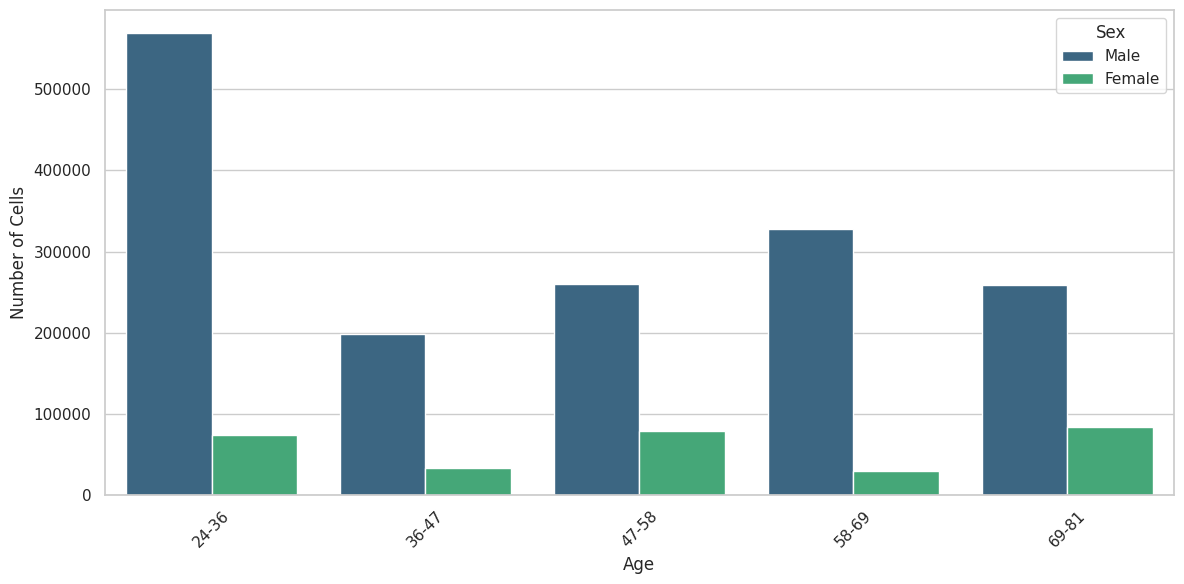

In [7]:


plt.figure(figsize=(12, 6))
sns.countplot(data=obs, x='age_bins', hue='Sex', palette='viridis')

plt.xlabel('Age')
plt.ylabel('Number of Cells')
plt.legend(title='Sex')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [20]:
obs.groupby(['Batch','Donor_id','Age']).size().sort_values()[::-1].head(10)

Batch  Donor_id  Age
AS062  E23       73     14152
AS051  C05       49     11448
AS052  D05       64     11358
       D02       61     11079
       FE01      80     10915
AS053  D09       61     10713
AS060  A28       25     10696
AS053  FE02      80     10613
       FE01      81     10102
       A04       32      9818
dtype: int64

# Batch correction

In [12]:
import anndata as ad 
adata = ad.read_h5ad('/vol/projects/CIIM/Healthy_Single_Cell_Data/count_matrix/data4_CMtx.h5ad')

In [13]:
adata = adata[:1000, :1000]

In [15]:
def run_classifier(adata, model_type='GB', confounder='donor_id', covariate='age', normalize=True):
    import lightgbm as lgb
    from sklearn.linear_model import RidgeClassifier, Ridge
    from sklearn.metrics import r2_score, make_scorer, accuracy_score
    from sklearn.model_selection import cross_validate
    from sklearn.preprocessing import MaxAbsScaler 
    import scanpy as sc  
    
    if normalize:
        print('normalize start')
        sc.pp.normalize_total(adata)
        sc.pp.log1p(adata)
        sc.pp.scale(adata)
        print('normalize end')
    
    scores = {}
    # classifer for confounder
    y = adata.obs[confounder]
    X = adata.X
    print('Batch classifier')
    if model_type=='ridge':
        model = RidgeClassifier(alpha=1)
        X = MaxAbsScaler().fit_transform(X)
    elif model_type=='GB':
        model = lgb.LGBMClassifier(silent=True, verbose=-1, n_jobs=20)
    else: 
        raise ValueError('Define the classifier')
    
    scoring = {
        'accuracy_score': make_scorer(accuracy_score)
    }
    score = 1 - cross_validate(model, X, y, cv=5, scoring=scoring, return_train_score=False)['test_accuracy_score'].mean()
    scores[confounder] = score
    scores[f"{confounder}_random_classifer_score"] = 1 - (1/y.nunique())
    # regressor for covariate
    print('Age regressor')
    if model_type=='ridge':
        model = Ridge(alpha=1)
        X = MaxAbsScaler().fit_transform(adata.X)
    elif model_type=='GB':
        model = lgb.LGBMRegressor(silent=True, verbose=-1, n_jobs=20)
    else: 
        raise ValueError('Define the classifier')
    y = adata.obs[covariate]
    scoring = {
        'r2_score': make_scorer(r2_score)
    }
    score = cross_validate(model, X, y, cv=5, scoring=scoring, return_train_score=False)['test_r2_score'].mean()
    scores[covariate] = score
    return scores
# run_classifier(adata)